# Parallel and Bypass Configurations

**Prerequisites:** [00h_connecting_units_in_series](./00h_connecting_units_in_series.ipynb)

**Learning Objectives:**
- Use splitters to divide streams
- Use mixers to combine streams
- Design parallel processing paths
- Implement bypass for temperature control

---

## Why Parallel and Bypass?

Real processes often need:
- **Parallel paths:** Process large flows in multiple smaller units
- **Bypass:** Blend hot and cold streams for temperature control
- **Split processing:** Different treatment for different fractions

These require **splitters** (divide one stream into many) and **mixers** (combine many into one).

In [1]:
# Setup
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from difflow import (Heater, HeaterParams, make_stream, get_flows, combine_streams, 
                     scale_stream, IdealThermo, SpeciesData)

In [2]:
# Define species
species_data = {
    'A': SpeciesData(name='A', MW=50.0, Cp_coeffs=(50.0, 0, 0, 0),
                    Hvap_coeffs=(30000.0, 0.38, 400.0),
                    antoine_coeffs=(10.0, 2000.0, -40.0)),
}
thermo = IdealThermo(species_data)

## Splitters and Mixers

### Splitter
Divides a stream based on a **split fraction** $\alpha$:

$$F_{out,1} = \alpha \cdot F_{in}$$
$$F_{out,2} = (1-\alpha) \cdot F_{in}$$

### Mixer  
Combines streams by adding flows:

$$F_{out} = F_{in,1} + F_{in,2}$$

In [3]:
# Implement splitter

def splitter(inlet, alpha):
    """
    Split a stream into two.
    
    Args:
        inlet: Input stream
        alpha: Fraction going to stream 1 (0 to 1)
    
    Returns:
        stream1, stream2: Two outlet streams
    """
    stream1 = scale_stream(inlet, alpha)
    stream2 = scale_stream(inlet, 1.0 - alpha)
    return stream1, stream2

# Test splitter
feed = make_stream({'A': 100.0}, T=300.0, P=101325.0)
stream1, stream2 = splitter(feed, alpha=0.7)

print("Splitter Test (α = 0.7)")
print("=" * 40)
print(f"Feed:    F_A = {float(get_flows(feed)['A']):.1f} mol/s")
print(f"Stream 1: F_A = {float(get_flows(stream1)['A']):.1f} mol/s (70%)")
print(f"Stream 2: F_A = {float(get_flows(stream2)['A']):.1f} mol/s (30%)")

Splitter Test (α = 0.7)
Feed:    F_A = 100.0 mol/s
Stream 1: F_A = 70.0 mol/s (70%)
Stream 2: F_A = 30.0 mol/s (30%)


In [4]:
# Implement mixer with energy balance

def mixer(stream1, stream2):
    """
    Mix two streams.
    
    Temperature is flow-weighted average (assuming same Cp).
    """
    flows1 = get_flows(stream1)
    flows2 = get_flows(stream2)
    
    F1_total = sum(flows1.values())
    F2_total = sum(flows2.values())
    F_total = F1_total + F2_total
    
    # Combined flows
    combined_flows = {k: flows1[k] + flows2[k] for k in flows1}
    
    # Flow-weighted temperature
    T_mix = (F1_total * stream1['T'] + F2_total * stream2['T']) / F_total
    
    # Take lower pressure
    P_mix = jnp.minimum(stream1['P'], stream2['P'])
    
    return make_stream(combined_flows, T=T_mix, P=P_mix)

# Test mixer
hot_stream = make_stream({'A': 70.0}, T=400.0, P=101325.0)
cold_stream = make_stream({'A': 30.0}, T=300.0, P=101325.0)
mixed = mixer(hot_stream, cold_stream)

print("\nMixer Test")
print("=" * 40)
print(f"Hot stream:  F_A = {float(get_flows(hot_stream)['A']):.0f} mol/s, T = {float(hot_stream['T']):.0f} K")
print(f"Cold stream: F_A = {float(get_flows(cold_stream)['A']):.0f} mol/s, T = {float(cold_stream['T']):.0f} K")
print(f"Mixed:       F_A = {float(get_flows(mixed)['A']):.0f} mol/s, T = {float(mixed['T']):.0f} K")


Mixer Test
Hot stream:  F_A = 70 mol/s, T = 400 K
Cold stream: F_A = 30 mol/s, T = 300 K
Mixed:       F_A = 100 mol/s, T = 370 K


## Bypass Configuration

A **bypass** sends part of a stream around a unit (typically a heater/cooler) for temperature control:

```
              ┌──────────────────────────────────┐
              │           Bypass (1-α)           │
              │                                  ▼
  Feed ───►Splitter                           Mixer───► Product
              │                                  ▲
              └──► Heater ──► Heated (α) ────────┘
```

By adjusting $\alpha$, we can achieve any temperature between inlet and heater outlet.

In [5]:
# Implement bypass configuration

heater = Heater(HeaterParams(Cp=50.0))

def heater_with_bypass(inlet, T_heater_out, alpha):
    """
    Heater with bypass for temperature control.
    
    The heater raises its portion to T_heater_out.
    Bypass stream remains at inlet temperature.
    Mixed outlet temperature depends on bypass fraction.
    
    Args:
        inlet: Feed stream
        T_heater_out: Target temperature for heated portion (K)
        alpha: Fraction going through heater (0 to 1)
    
    Returns:
        outlet: Mixed outlet stream
        info: dict with intermediate streams
    """
    # Split
    to_heater, bypass = splitter(inlet, alpha)
    
    # Heat to target temperature
    heated, heater_info = heater(to_heater, T_out=T_heater_out)
    
    # Mix heated + bypass
    outlet = mixer(heated, bypass)
    
    return outlet, {
        'to_heater': to_heater,
        'bypass': bypass,
        'heated': heated,
        'heater_Q': heater_info['Q'],
    }

# Example: Heat a stream with bypass control
feed = make_stream({'A': 100.0}, T=300.0, P=101325.0)
T_heater_target = 400.0  # Heater heats its portion to 400 K

# Try different bypass fractions
print("Heater with Bypass - Temperature Control")
print("=" * 55)
print(f"Feed: {float(get_flows(feed)['A']):.0f} mol/s at {float(feed['T']):.0f} K")
print(f"Heater outlet target: {T_heater_target:.0f} K")
print(f"")
print(f"{'Bypass %':<12} {'To heater':<12} {'Heated T':<12} {'Mixed T':<12} {'Q (kW)':<12}")
print("-" * 60)

for bypass_frac in [0.0, 0.2, 0.4, 0.6, 0.8]:
    alpha = 1.0 - bypass_frac
    outlet, info = heater_with_bypass(feed, T_heater_target, alpha)
    Q_kW = float(info['heater_Q']) / 1000
    print(f"{bypass_frac*100:<12.0f} {float(get_flows(info['to_heater'])['A']):<12.0f} "
          f"{float(info['heated']['T']):<12.0f} {float(outlet['T']):<12.0f} {Q_kW:<12.0f}")

Heater with Bypass - Temperature Control
Feed: 100 mol/s at 300 K
Heater outlet target: 400 K

Bypass %     To heater    Heated T     Mixed T      Q (kW)      
------------------------------------------------------------
0            100          400          400          500         
20           80           400          380          400         
40           60           400          360          300         
60           40           400          340          200         
80           20           400          320          100         


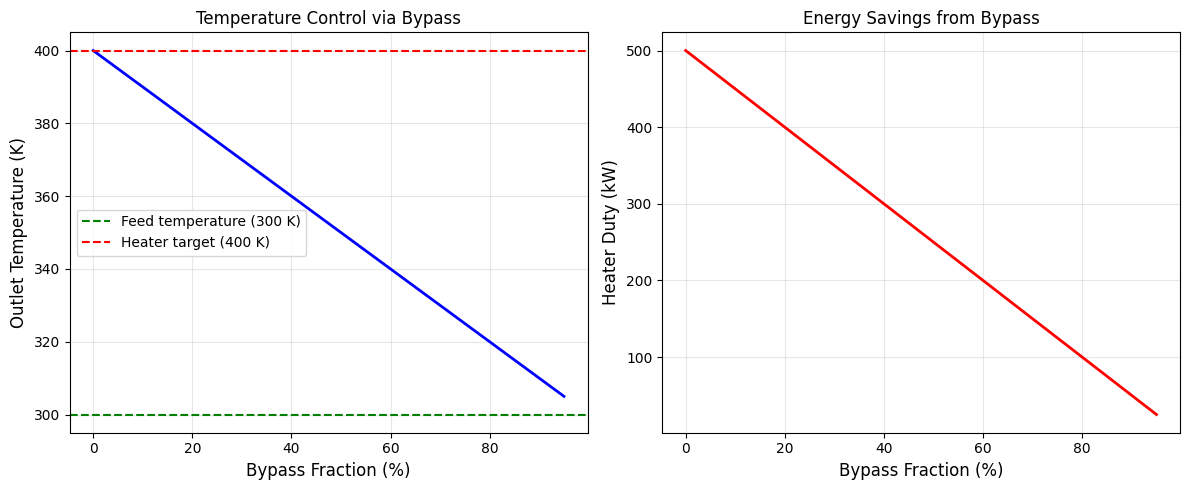

In [6]:
# Visualize bypass effect

bypass_fractions = [i/20 for i in range(20)]  # 0 to 95%
outlet_temps = []
heater_duties = []

for bypass_frac in bypass_fractions:
    alpha = 1.0 - bypass_frac
    if alpha > 0.01:  # Avoid division issues
        outlet, info = heater_with_bypass(feed, T_heater_target, alpha)
        outlet_temps.append(float(outlet['T']))
        heater_duties.append(float(info['heater_Q']) / 1000)  # kW
    else:
        outlet_temps.append(float(feed['T']))  # 100% bypass = feed temp
        heater_duties.append(0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Temperature vs bypass
ax1.plot([f*100 for f in bypass_fractions], outlet_temps, 'b-', linewidth=2)
ax1.axhline(y=float(feed['T']), color='g', linestyle='--', label='Feed temperature (300 K)')
ax1.axhline(y=T_heater_target, color='r', linestyle='--', label='Heater target (400 K)')
ax1.set_xlabel('Bypass Fraction (%)', fontsize=12)
ax1.set_ylabel('Outlet Temperature (K)', fontsize=12)
ax1.set_title('Temperature Control via Bypass', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Heat duty vs bypass
ax2.plot([f*100 for f in bypass_fractions], heater_duties, 'r-', linewidth=2)
ax2.set_xlabel('Bypass Fraction (%)', fontsize=12)
ax2.set_ylabel('Heater Duty (kW)', fontsize=12)
ax2.set_title('Energy Savings from Bypass', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

## Parallel Processing

For large flows or redundancy, we can use parallel units:

```
              ┌──► Reactor 1 ──┐
              │                │
  Feed ───►Splitter          Mixer───► Product
              │                │
              └──► Reactor 2 ──┘
```

In [7]:
from difflow import CSTR, CSTRParams

# Two parallel reactors with different conditions

def rate_fn(C, T, params):
    return jnp.array([params['k'] * C['A']])

stoich = jnp.array([[-1.0]])  # A consumed (simplified, no product B)

# Reactor 1: Smaller, lower k
cstr1_params = CSTRParams(
    V=jnp.array(1.0),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(0.3)},
    species_order=['A'],
)
reactor1 = CSTR(cstr1_params, thermo=thermo, mode='isothermal')

# Reactor 2: Larger, higher k
cstr2_params = CSTRParams(
    V=jnp.array(2.0),
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(0.5)},
    species_order=['A'],
)
reactor2 = CSTR(cstr2_params, thermo=thermo, mode='isothermal')

def parallel_reactors(feed, alpha, Q_vol):
    """
    Process feed through two parallel reactors.
    
    Args:
        feed: Feed stream
        alpha: Fraction to reactor 1
        Q_vol: Total volumetric flow rate
    """
    # Split feed
    feed1, feed2 = splitter(feed, alpha)
    
    # Process in parallel
    out1, info1 = reactor1(feed1, T_spec=350.0, volumetric_flow=alpha*Q_vol)
    out2, info2 = reactor2(feed2, T_spec=350.0, volumetric_flow=(1-alpha)*Q_vol)
    
    # Combine outputs
    combined = mixer(out1, out2)
    
    return combined, info1, info2

# Test
feed = make_stream({'A': 100.0}, T=300.0, P=101325.0)
Q_vol = 0.1  # m³/s total

print("Parallel Reactors")
print("=" * 50)

for alpha in [0.0, 0.25, 0.5, 0.75, 1.0]:
    if 0.01 < alpha < 0.99:
        combined, info1, info2 = parallel_reactors(feed, alpha, Q_vol)
        X1 = float(info1['conversion']['A'])
        X2 = float(info2['conversion']['A'])
        F_out = float(get_flows(combined)['A'])
        X_overall = (100.0 - F_out) / 100.0
        print(f"Split {alpha*100:.0f}%/{(1-alpha)*100:.0f}%: X1={X1*100:.1f}%, X2={X2*100:.1f}%, Overall X={X_overall*100:.1f}%")

Parallel Reactors


Split 25%/75%: X1=92.3%, X2=93.0%, Overall X=92.8%


Split 50%/50%: X1=85.7%, X2=95.2%, Overall X=90.5%


Split 75%/25%: X1=80.0%, X2=97.6%, Overall X=84.4%


## Try It Yourself!

### Exercise 1: Optimal Bypass
Find the bypass fraction that achieves exactly T = 350 K outlet temperature (use the heater example).

### Exercise 2: Parallel with Different T
Modify the parallel reactor example so reactor 1 operates at 330 K and reactor 2 at 380 K. What split ratio maximizes overall conversion?

### Exercise 3: Three-Way Split
Implement a 3-way splitter and design a system with three parallel heaters.

---

## Key Takeaways

1. **Splitter:** $F_{out} = \alpha \cdot F_{in}$ (compositions unchanged)
2. **Mixer:** $F_{out} = \sum F_{in}$ with flow-weighted temperature
3. **Bypass:** Provides continuous temperature control
4. **Parallel paths:** Enable redundancy and flexibility

---

## Next Steps

In the next notebook (**[00j: Recycle Streams](./00j_recycle_streams.ipynb)**), we'll tackle:
- Why recycles create circular dependencies
- Fixed-point iteration for recycles
- Convergence and tear streams